# AI Engineer EDA

In [4]:
# task 1 load
import pandas as pd

# Load directly from URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.describe())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

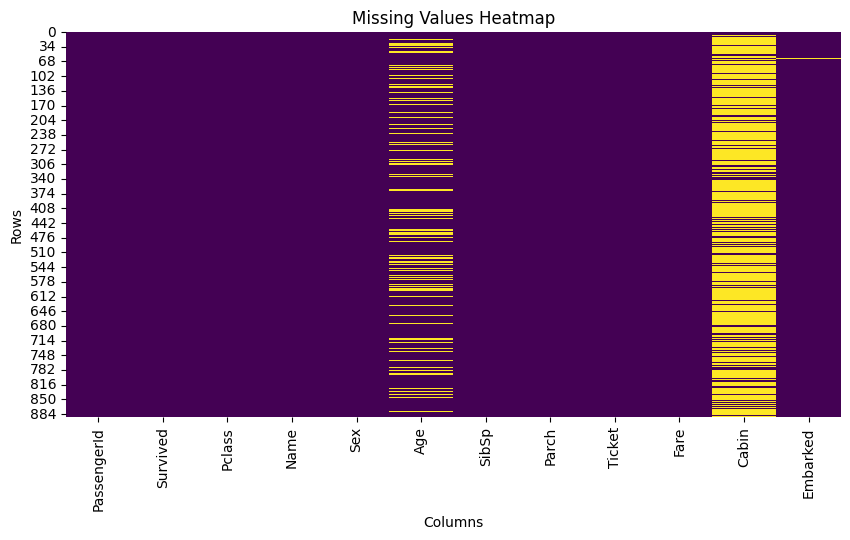

In [6]:
# visualize the heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [8]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [10]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df=df.drop("Cabin",axis=1)

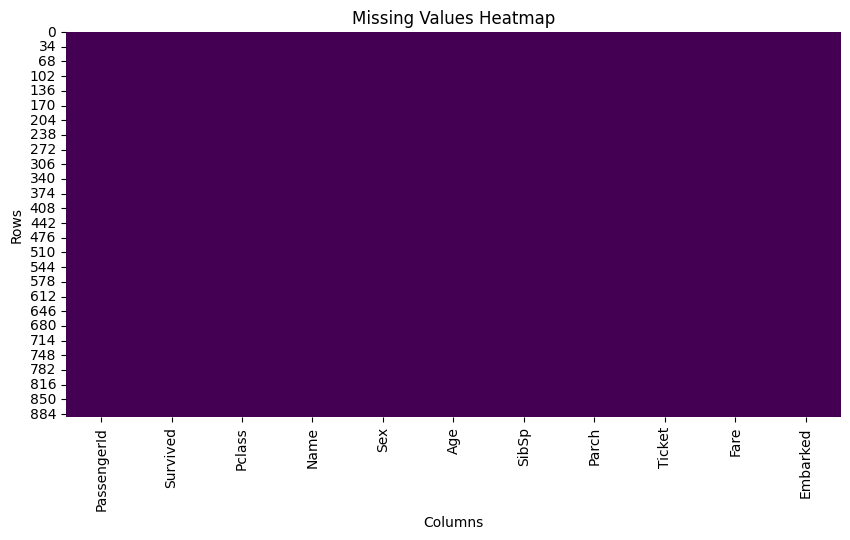

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

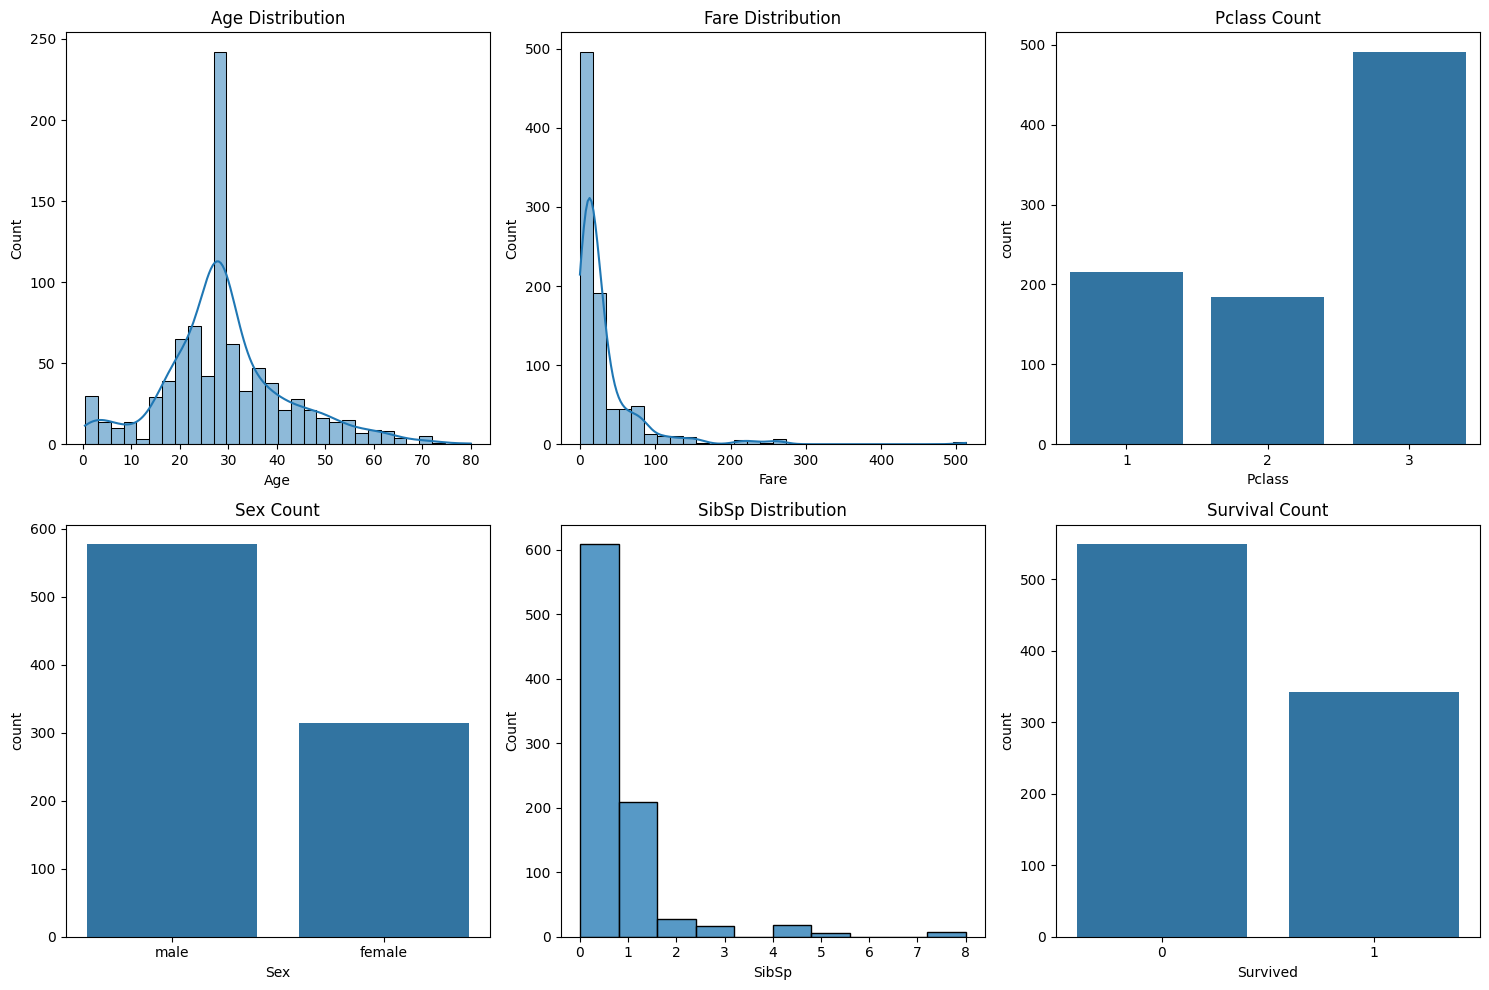

In [17]:
# sub plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Age histogram
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

# Fare histogram
sns.histplot(df['Fare'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Fare Distribution")

# Pclass bar chart
sns.countplot(x='Pclass', data=df, ax=axes[0,2])
axes[0,2].set_title("Pclass Count")

# Sex bar chart
sns.countplot(x='Sex', data=df, ax=axes[1,0])
axes[1,0].set_title("Sex Count")

# SibSp histogram
sns.histplot(df['SibSp'], bins=10, kde=False, ax=axes[1,1])
axes[1,1].set_title("SibSp Distribution")

# Survived bar chart
sns.countplot(x='Survived', data=df, ax=axes[1,2])
axes[1,2].set_title("Survival Count")

plt.tight_layout()
plt.show()

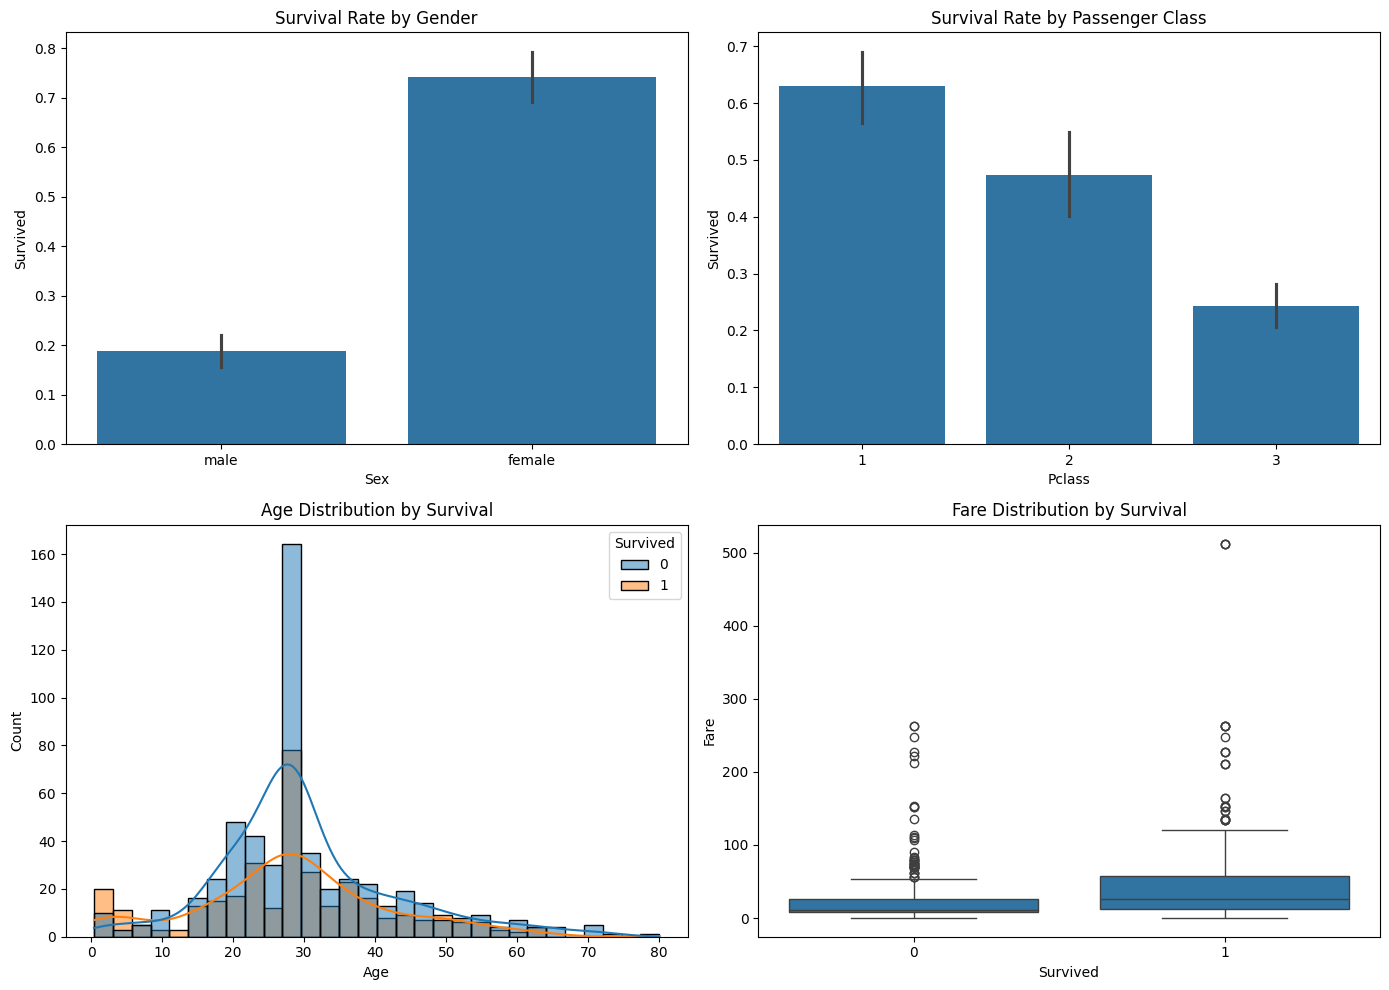

In [18]:
# task 4
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival rate by Gender
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title("Survival Rate by Gender")

# 2. Survival rate by Pclass
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title("Survival Rate by Passenger Class")

# 3. Age distribution by Survival
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Age Distribution by Survival")

# 4. Fare distribution by Survival
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1,1])
axes[1,1].set_title("Fare Distribution by Survival")

plt.tight_layout()
plt.show()

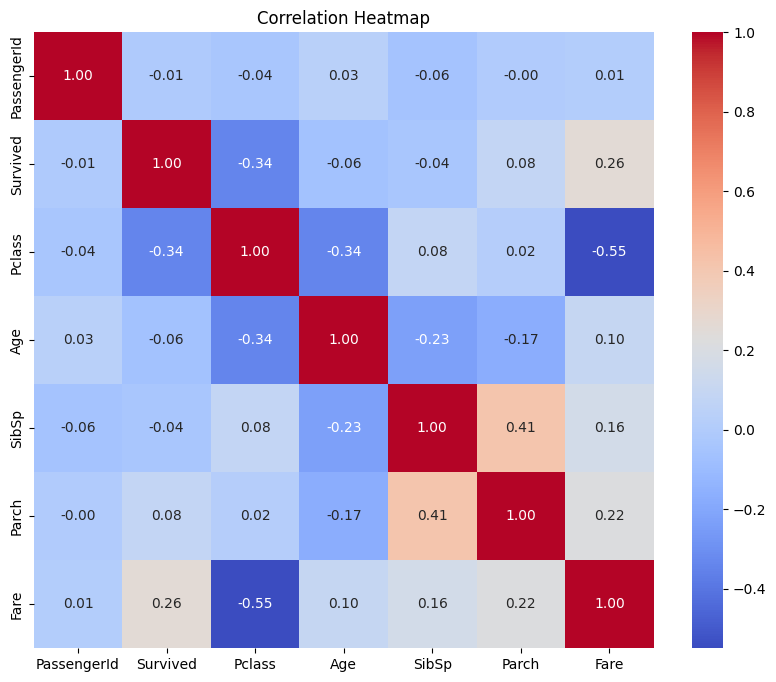

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# ### Observations from Correlation Heatmap

1. **Survived and Pclass** show a negative correlation, meaning passengers in higher classes (lower Pclass value) had a better chance of survival.

2. **Fare and Pclass** are strongly negatively correlated, indicating that passengers in higher classes paid higher fares.

3. **SibSp and Parch** show a slight positive correlation, suggesting that passengers traveling with siblings/spouses often also traveled with parents/children.
